<a href="https://www.kaggle.com/code/sonawanelalitsunil/analyzing-student-academic-trends-ml-85-38?scriptVersionId=261932586" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/analyzing-student-academic-trends/student_exam_scores.csv


## Title: Analyzing Student Academic Trends

## Description:
This analysis focuses on understanding patterns in student academic performance across various factors such as grades, attendance, study habits, and participation. By identifying trends over time, we can uncover key insights into how different variables influence academic outcomes. The study also aims to highlight challenges faced by students, recognize areas for improvement, and recommend strategies to enhance learning experiences. These insights can assist educators, institutions, and policymakers in making data-driven decisions to support student success and improve overall academic standards.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/analyzing-student-academic-trends/student_exam_scores.csv")

In [3]:
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [4]:
df.tail()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
195,S196,10.5,5.4,94.0,87,42.7
196,S197,7.1,6.1,85.1,92,40.4
197,S198,1.6,6.9,63.8,76,28.2
198,S199,12.0,7.3,50.5,58,42.0
199,S200,10.2,6.3,97.4,68,37.8


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


In [6]:
df.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [7]:
df.isnull().sum()

student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

student_id             object
hours_studied         float64
sleep_hours           float64
attendance_percent    float64
previous_scores         int64
exam_score            float64
dtype: object

In [10]:
df.shape

(200, 6)

In [11]:
df.columns

Index(['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent',
       'previous_scores', 'exam_score'],
      dtype='object')

## Data visualizations

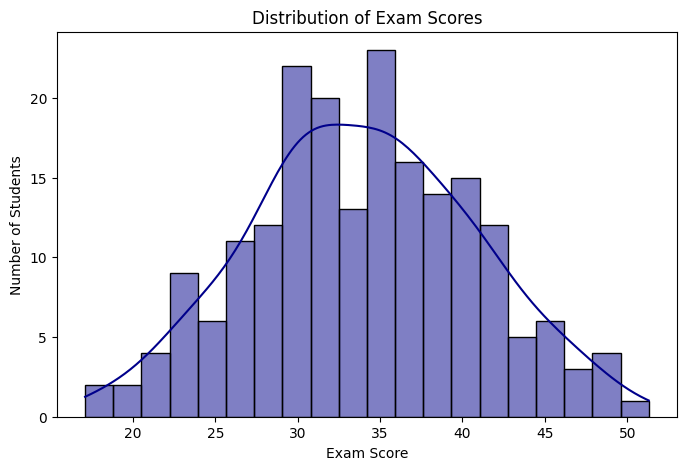

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['exam_score'], kde=True, bins=20, color="darkblue")
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()


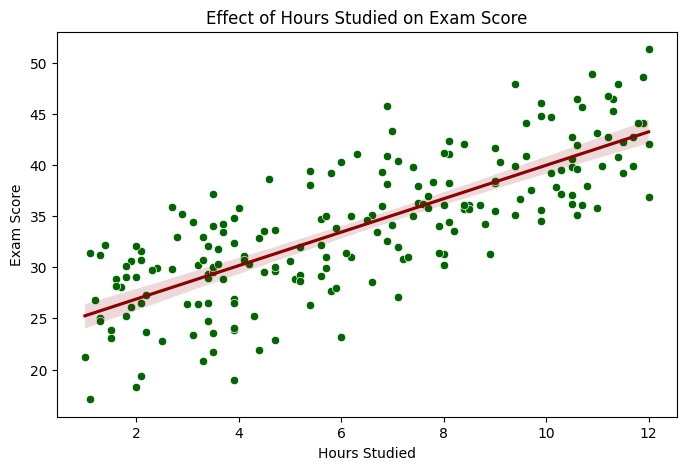

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="hours_studied", y="exam_score", data=df, color="darkgreen")
sns.regplot(x="hours_studied", y="exam_score", data=df, scatter=False, color="darkred")
plt.title("Effect of Hours Studied on Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

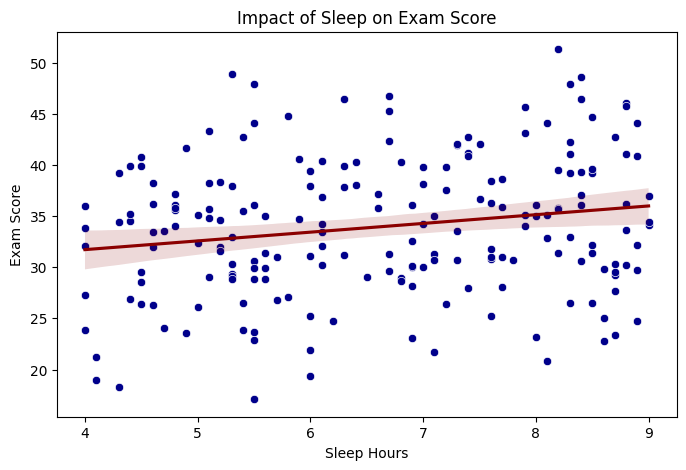

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="sleep_hours", y="exam_score", data=df, color="darkblue")
sns.regplot(x="sleep_hours", y="exam_score", data=df, scatter=False, color="darkred")
plt.title("Impact of Sleep on Exam Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Exam Score")
plt.show()

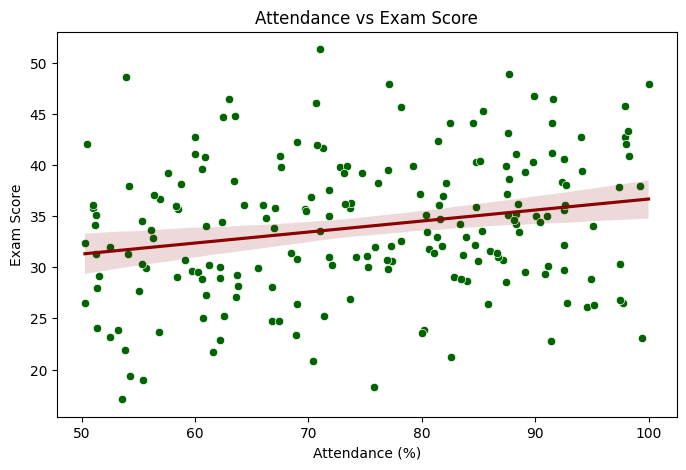

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="attendance_percent", y="exam_score", data=df, color="darkgreen")
sns.regplot(x="attendance_percent", y="exam_score", data=df, scatter=False, color="darkred")
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.show()

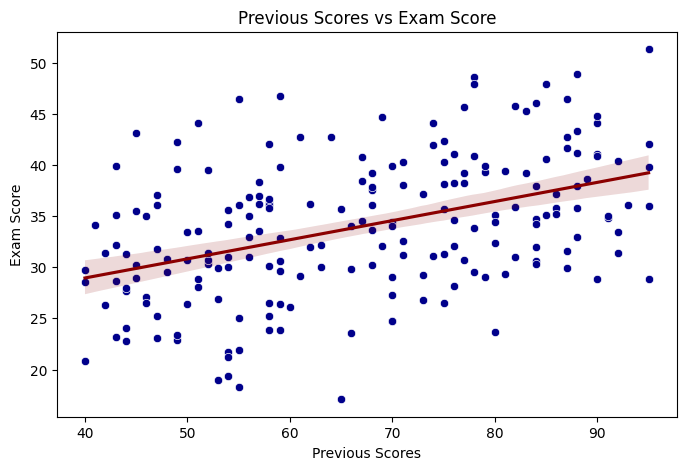

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="previous_scores", y="exam_score", data=df, color="darkblue")
sns.regplot(x="previous_scores", y="exam_score", data=df, scatter=False, color="darkred")
plt.title("Previous Scores vs Exam Score")
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")
plt.show()

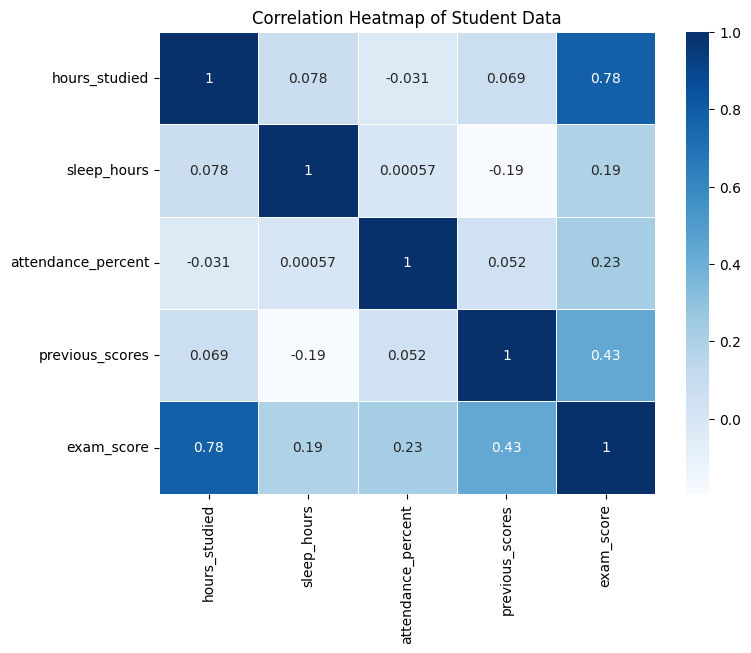

In [17]:
plt.figure(figsize=(8,6))
corr = df[['hours_studied','sleep_hours','attendance_percent','previous_scores','exam_score']].corr()
sns.heatmap(corr, annot=True, cmap="Blues", linewidths=0.5)
plt.title("Correlation Heatmap of Student Data")
plt.show()

## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [19]:
X = df[['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']]
y = df['exam_score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [20]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "KNN Regressor": KNeighborsRegressor()
}


In [21]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred) * 100  # convert to percentage
    results[name] = round(r2, 2)


In [22]:
print("Model Accuracy (R² Score in %):")
for model, acc in results.items():
    print(f"{model}: {acc}%")

Model Accuracy (R² Score in %):
Linear Regression: 85.37%
Ridge Regression: 85.38%
Lasso Regression: 74.88%
Decision Tree: 53.34%
Random Forest: 79.44%
Gradient Boosting: 77.69%
Support Vector Regressor: 69.95%
KNN Regressor: 78.21%


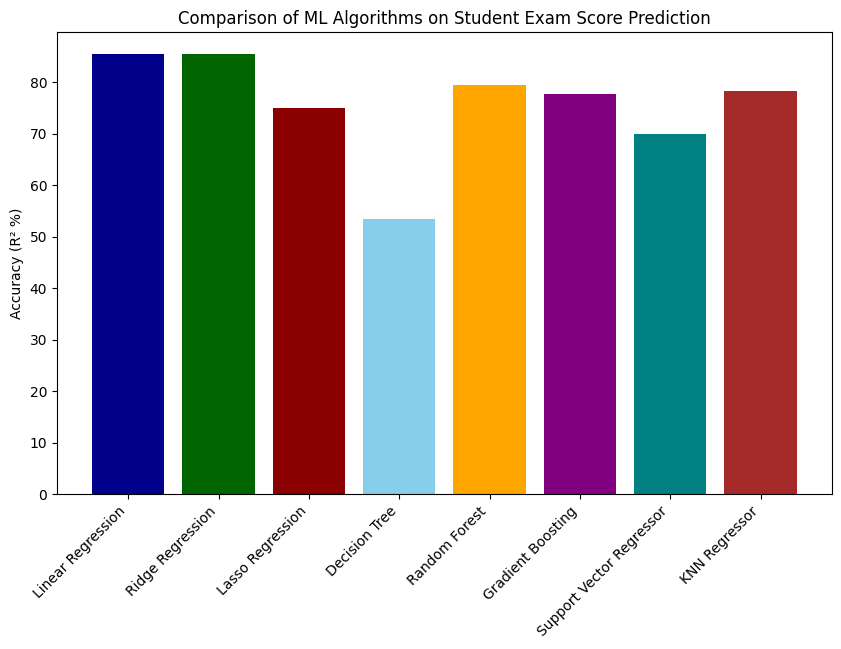

In [23]:
plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values(), color=['darkblue','darkgreen','darkred','skyblue','orange','purple','teal','brown'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy (R² %)") 
plt.title("Comparison of ML Algorithms on Student Exam Score Prediction")
plt.show()